**다중**
- 2, 1, 0 3개 단계로 나눔 (30, 30, 40)

Confusion Matrix:
[[428 223 243]
 [321 169 198]
 [327 150 221]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.40      0.48      0.43       894
         1.0       0.31      0.25      0.27       688
         2.0       0.33      0.32      0.33       698

    accuracy                           0.36      2280
   macro avg       0.35      0.35      0.34      2280
weighted avg       0.35      0.36      0.35      2280



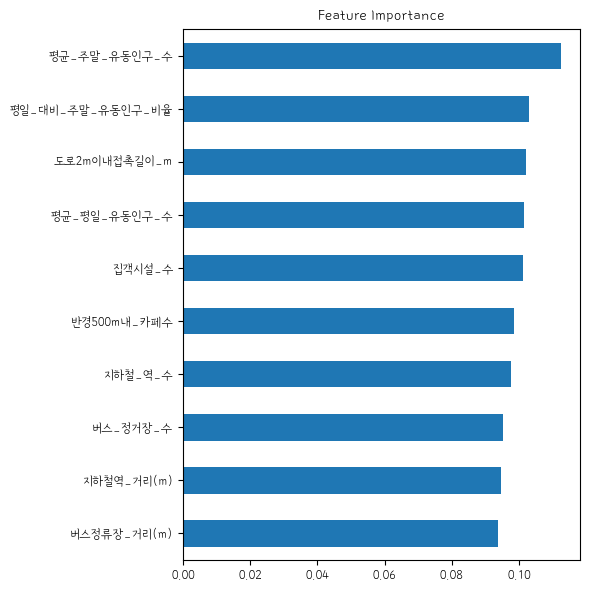

In [3]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager, rc
# 한글 폰트 설정
font_path = r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\fonts\강원교육모두 Light.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False


# 데이터 로딩
cafe = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_피처병합_다중.csv')
cafe_cleaned = cafe.dropna(subset=['총점', '성공_여부', '교차로_존재_여부', 'est_총_유동인구_수']).copy()
cafe_cleaned['교차로_존재_여부'] = cafe_cleaned['교차로_존재_여부'].astype(int)
cafe_cleaned[['집객시설_수', '지하철_역_수','버스_정거장_수','유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수']] = \
    cafe_cleaned[['집객시설_수', '지하철_역_수','버스_정거장_수','유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수']].fillna(0)

# 층수 처리
def convert_floor(floor):
    try:
        if isinstance(floor, str) and floor.startswith('B'):
            return -int(floor[1:])
        elif isinstance(floor, str) and floor.startswith('지'):
            return -1
        else:
            return int(floor)
    except:
        return 1
cafe_cleaned['층정보'] = cafe_cleaned['층정보'].apply(convert_floor)

# 특징 및 타겟
train_cols = ['지하철역_거리(m)','버스정류장_거리(m)','반경500m내_카페수', '평일_대비_주말_유동인구_비율',
              '도로2m이내접촉길이_m','집객시설_수', '지하철_역_수','버스_정거장_수',
              '평균_평일_유동인구_수', '평균_주말_유동인구_수']
X = cafe_cleaned[train_cols]
y = cafe_cleaned['성공_여부']  # 다중 클래스 (0, 1, 2)

# 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# -----------------------------
# ✅ XGBClassifier (다중분류용)
# -----------------------------
xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    max_depth=6,
    n_estimators=100,
    random_state=42,
    eval_metric='mlogloss'
)

# 훈련
xgb_model.fit(X_train, y_train)

# 예측 (확률)
y_proba = xgb_model.predict_proba(X_test)  # shape: (n_samples, 3)

# 가장 확률 높은 클래스 선택
y_pred = np.argmax(y_proba, axis=1)

# 평가
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance 시각화
feat_importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importance.sort_values(ascending=True).plot(kind='barh', figsize=(6, 6), title='Feature Importance')
plt.tight_layout()
plt.show()


Confusion Matrix:
[[310 267 317]
 [226 216 246]
 [191 187 320]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.43      0.35      0.38       894
         1.0       0.32      0.31      0.32       688
         2.0       0.36      0.46      0.40       698

    accuracy                           0.37      2280
   macro avg       0.37      0.37      0.37      2280
weighted avg       0.38      0.37      0.37      2280

ROC AUC Score (macro avg): 0.5440


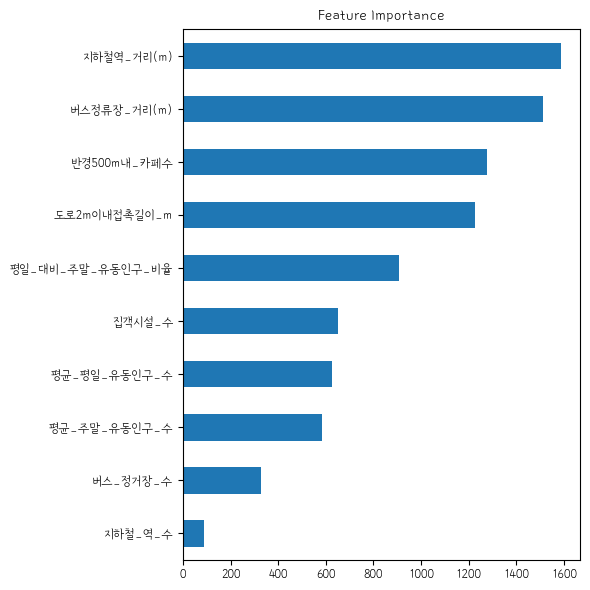

In [5]:
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

# 한글 폰트 설정
font_path = r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\fonts\강원교육모두 Light.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로딩 및 전처리
cafe = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_피처병합_다중.csv')
cafe_cleaned = cafe.dropna(subset=['총점', '성공_여부', '교차로_존재_여부', 'est_총_유동인구_수']).copy()
cafe_cleaned['교차로_존재_여부'] = cafe_cleaned['교차로_존재_여부'].astype(int)
cafe_cleaned[['집객시설_수', '지하철_역_수','버스_정거장_수','유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수']] = \
    cafe_cleaned[['집객시설_수', '지하철_역_수','버스_정거장_수','유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수']].fillna(0)

# 층수 처리
def convert_floor(floor):
    try:
        if isinstance(floor, str) and floor.startswith('B'):
            return -int(floor[1:])
        elif isinstance(floor, str) and floor.startswith('지'):
            return -1
        else:
            return int(floor)
    except:
        return 1
cafe_cleaned['층정보'] = cafe_cleaned['층정보'].apply(convert_floor)

# 피처 및 타겟 정의
train_cols = ['지하철역_거리(m)', '버스정류장_거리(m)', '반경500m내_카페수',
              '평일_대비_주말_유동인구_비율', '도로2m이내접촉길이_m',
              '집객시설_수', '지하철_역_수', '버스_정거장_수',
              '평균_평일_유동인구_수', '평균_주말_유동인구_수']
X = cafe_cleaned[train_cols]
y = cafe_cleaned['성공_여부']  # 다중 클래스: 0, 1, 2

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# LightGBM 모델 정의 (다중 분류)
lgb_params = {
    'objective': 'multiclass',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'min_data_in_leaf': 10,
    'max_depth': 6,
    'num_class': 3,  # 클래스 수 명시
    'verbose': -1
}
lgbm_model = LGBMClassifier(**lgb_params, n_estimators=100, class_weight='balanced')

# 모델 학습
lgbm_model.fit(X_train, y_train)

# 예측 (확률 -> 예측 클래스)
y_proba = lgbm_model.predict_proba(X_test)
y_pred = y_proba.argmax(axis=1)

# 평가 지표 출력
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

try:
    auc_score = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
    print(f"ROC AUC Score (macro avg): {auc_score:.4f}")
except:
    print("ROC AUC 계산에 실패했습니다.")

# Feature Importance 시각화
feat_importance = pd.Series(lgbm_model.feature_importances_, index=X.columns)
feat_importance.sort_values(ascending=True).plot(kind='barh', figsize=(6, 6), title='Feature Importance')
plt.tight_layout()
plt.show()


Confusion Matrix:
[[307 274 313]
 [243 216 229]
 [210 202 286]]

Classification Report:
              precision    recall  f1-score   support

         0.0     0.4039    0.3434    0.3712       894
         1.0     0.3121    0.3140    0.3130       688
         2.0     0.3454    0.4097    0.3748       698

    accuracy                         0.3548      2280
   macro avg     0.3538    0.3557    0.3530      2280
weighted avg     0.3583    0.3548    0.3548      2280



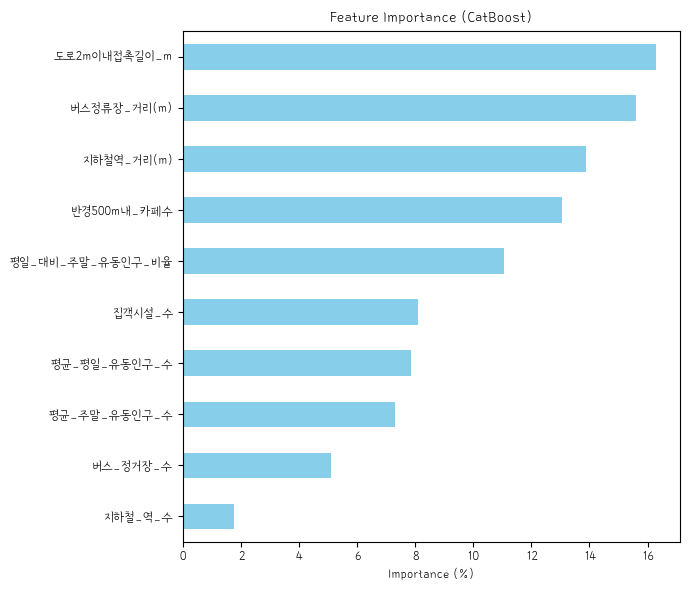

In [6]:
from catboost import CatBoostClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

# 📌 한글 폰트 설정
font_path = r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\fonts\강원교육모두 Light.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# 📌 데이터 불러오기 및 전처리
cafe = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_피처병합_다중.csv')
cafe_cleaned = cafe.dropna(subset=['총점', '성공_여부', '교차로_존재_여부', 'est_총_유동인구_수']).copy()
cafe_cleaned['교차로_존재_여부'] = cafe_cleaned['교차로_존재_여부'].astype(int)

# 결측치 0으로 처리
fill_cols = ['집객시설_수', '지하철_역_수', '버스_정거장_수', '유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수']
cafe_cleaned[fill_cols] = cafe_cleaned[fill_cols].fillna(0)

# 층정보 처리 함수
def convert_floor(floor):
    try:
        if isinstance(floor, str) and floor.startswith('B'):
            return -int(floor[1:])
        elif isinstance(floor, str) and floor.startswith('지'):
            return -1
        else:
            return int(floor)
    except:
        return 1  # 오류 시 1층으로 처리

cafe_cleaned['층정보'] = cafe_cleaned['층정보'].apply(convert_floor)

# 📌 학습용 피처 및 타겟 설정 (3클래스 타겟)
train_cols = ['지하철역_거리(m)', '버스정류장_거리(m)', '반경500m내_카페수', '평일_대비_주말_유동인구_비율',
              '도로2m이내접촉길이_m', '집객시설_수', '지하철_역_수', '버스_정거장_수',
              '평균_평일_유동인구_수', '평균_주말_유동인구_수']
X = cafe_cleaned[train_cols]
y = cafe_cleaned['성공_여부']  # 📌 반드시 클래스가 0, 1, 2 등 3개여야 함

# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 📌 CatBoost 모델 학습 (다중분류)
cat_model = CatBoostClassifier(auto_class_weights='Balanced', iterations=100, depth=6, random_state=42, verbose=0)
cat_model.fit(X_train, y_train)

# 📌 예측 및 평가
y_pred = cat_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# 📌 피처 중요도 시각화
feat_importance = pd.Series(cat_model.feature_importances_, index=X.columns)
feat_importance.sort_values().plot(kind='barh', figsize=(7, 6), title='Feature Importance (CatBoost)', color='skyblue')
plt.xlabel('Importance (%)')
plt.tight_layout()
plt.show()


In [ ]:
# 데이터 가공 및 정리
import pandas as pd
import re
import numpy as np
import sys
sale = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\매물_피처병합_수정.csv', low_memory=False)

# print(sale.columns.tolist())
# 상권 내 매물이 아니면 drop
sale = sale.dropna(subset=['상권_코드','articleNo'])

# 금액 전환
def parse_price_to_manwon(price_str): # 금액 숫자로 전환
    if pd.isna(price_str):
        return np.nan
    price_str = str(price_str).strip().replace(",", "").replace(" ", "")
    
    if "억" in price_str:
        match = re.match(r"(\d+)억(\d+)?", price_str)
        if match:
            billion = int(match.group(1)) * 10000
            thousand = int(match.group(2)) if match.group(2) else 0
            return billion + thousand
        else:
            return int(price_str.replace("억", "")) * 10000
    elif price_str.isdigit():
        return int(price_str)
    else:
        return pd.to_numeric(price_str, errors='coerce')
sale['rentPrc'] = sale['rentPrc'].apply(parse_price_to_manwon)
sale['dealOrWarrantPrc'] = sale['dealOrWarrantPrc'].apply(parse_price_to_manwon)

# 결측치 처리
sale[['집객시설_수', '관공서_수', '은행_수', '종합병원_수', '일반_병원_수', '약국_수', '유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수', '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '지하철_역_수', '버스_정거장_수','반경500m내_카페수', '접한길이_m', '도로2m이내접착길이_m','지하철역_거리(m)', '버스정류장_거리(m)']] = sale[['집객시설_수', '관공서_수', '은행_수', '종합병원_수', '일반_병원_수', '약국_수', '유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수', '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '지하철_역_수', '버스_정거장_수','반경500m내_카페수', '접한길이_m', '도로2m이내접촉길이_m','지하철역_거리(m)', '버스정류장_거리(m)']].fillna(0)
# 컬럼명 오타 수정 (접착 → 접촉) # 완전 수정함

sale['est_총_유동인구_수'] = sale['est_총_유동인구_수'].fillna(sale['est_총_유동인구_수'].mean())

# 데이터 형식
sale['상권_코드'] = sale['상권_코드'].astype(int)
sale['교차로_존재_여부'] = sale['교차로_존재_여부'].astype(int)

# 사용자 실습
def recommend_top_properties(
    df, model, selected_areas, trade_type,
    max_rent=None, max_deposit=None, max_deal_price=None, top_n=5
):
    # 1. 상권, 거래유형 필터링
    filtered = df[
        (df['상권_코드'].isin(selected_areas)) &
        (df['tradeTypeName'] == trade_type)
    ].copy()

    # 2. 금액 조건 필터링
    if trade_type == '월세':
        filtered = filtered[
            (filtered['rentPrc'] <= max_rent) &
            (filtered['dealOrWarrantPrc'] <= max_deposit)
        ]
    elif trade_type == '매매':
        filtered = filtered[
            (filtered['dealOrWarrantPrc'] <= max_deal_price)
        ]

    # 3. 피처 선택
    X_test = filtered[model.feature_names_in_].copy()

    # 4. 성공 확률 예측
    filtered['성공확률'] = model.predict_proba(X_test)[:, 1]

    # 5. 확률 기준 정렬 및 상위 n개 추출
    top_recommendations = filtered.sort_values(by='성공확률', ascending=False).head(top_n)

    return top_recommendations.reset_index(drop=True)

recommendations = recommend_top_properties(
    sale,
    model=xgb_model, # 사용할 모델
    selected_areas=[3120104, 3120189], # 선택한 상권
    trade_type='월세', # 월세 / 전세 / 단기임대 / 매매 (월세, 매매가 제일 많음)
    max_rent=200, # 월세 상한선
    max_deposit=1000, # 보증금 상한선
    top_n=5 # 추천 받을 개수
)

print(recommendations[['articleNo', 'rentPrc', 'dealOrWarrantPrc', '성공확률']])
# 더 제공해 줄 수 있는 것 check


      articleNo  rentPrc  dealOrWarrantPrc      성공확률
0  2.519903e+09    120.0            1000.0  0.920718
1  2.521752e+09    120.0            1000.0  0.920718
2  2.521569e+09    120.0            1000.0  0.920718
3  2.522206e+09    126.0            1000.0  0.877406
4  2.524377e+09    110.0            1000.0  0.847014
